# Food Delivery Time Analysis

# IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOADING DATA SET

In [2]:
df = pd.read_csv("../data/Food_Delivery_Times.csv")

# Data Understanding

In [3]:
df.head()


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.shape


(1000, 9)

In [5]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

Data Types


In [6]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


# Missing Value Analysis

In [8]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [9]:
from sklearn.impute import SimpleImputer

# Numerical(numbers) columns
num_imputer = SimpleImputer(strategy='mean')

df['Courier_Experience_yrs'] = num_imputer.fit_transform(
    df[['Courier_Experience_yrs']]
)

# Categorical(text) columns
cat_imputer = SimpleImputer(strategy='most_frequent')

df[['Weather', 'Traffic_Level', 'Time_of_Day']] = cat_imputer.fit_transform(
    df[['Weather', 'Traffic_Level', 'Time_of_Day']]
)

In [10]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

# Duplicate Value Check

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.870301,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,4.579381,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


# Statistical Analysis

In [13]:
df['Delivery_Time_min'].mean()

np.float64(56.732)

On average, orders take approximately 57 minutes to be delivered.

In [14]:
df['Delivery_Time_min'].median()

55.5

In [15]:
df['Delivery_Time_min'].mode()

0    71
Name: Delivery_Time_min, dtype: int64

In [16]:
df['Delivery_Time_min'].std()

22.070915280098887

Delivery times vary by approximately 22 minutes from the average delivery time.

This indicates moderate variability in delivery performance.

In [17]:
df['Delivery_Time_min'].var()

487.1253013013025

In [18]:
df['Delivery_Time_min'].quantile([0.25,0.5,0.75])

0.25    41.0
0.50    55.5
0.75    71.0
Name: Delivery_Time_min, dtype: float64

Skewness

In [19]:
df['Delivery_Time_min'].skew()

np.float64(0.5072511816152696)

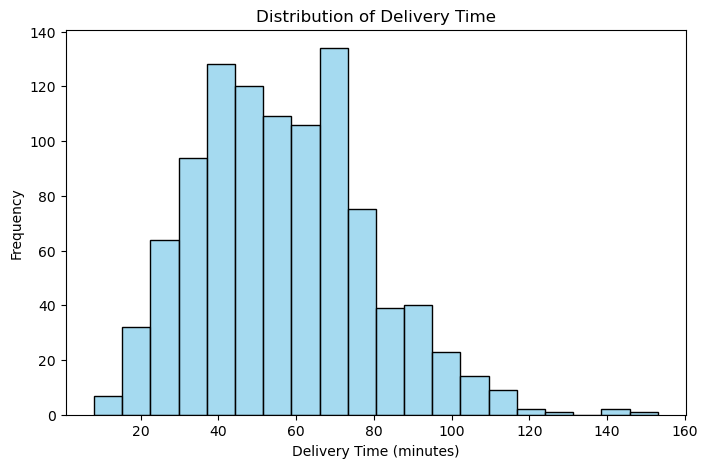

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Delivery_Time_min'], bins=20,color='skyblue', edgecolor='black')
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')

plt.savefig('../images/histogram.png')

plt.show()

The average delivery time was 56.73 minutes. The distribution of delivery time was positively skewed (skewness = 0.51), indicating that while most deliveries were completed within a typical time range, a small number of deliveries experienced significantly longer delays. The histogram confirmed this pattern by showing a longer tail toward higher delivery times. This suggests the presence of occasional extreme delays in the delivery process.

# Outliers

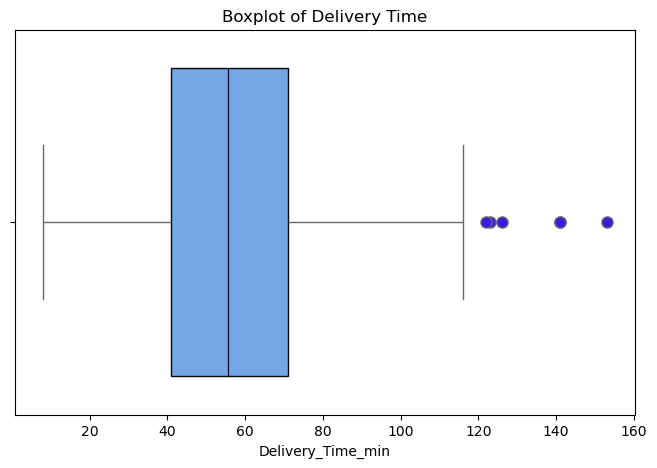

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Delivery_Time_min'],
    color='#60A5FA',
    
    boxprops=dict(
    edgecolor="#02060F",
    linewidth=1),

    medianprops=dict(
    color='#111827',
    linewidth=1),

     flierprops=dict(
        marker='o',
        markerfacecolor="#3E1AE0",
        markersize=8,
        linestyle='none'
    ))
plt.title('Boxplot of Delivery Time')
plt.savefig('../images/boxplot.png')
plt.show()

# Outliers by IQR Method

In [22]:
Q1 = df['Delivery_Time_min'].quantile(0.25)
Q3 = df['Delivery_Time_min'].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['Delivery_Time_min'] < lower_bound) |(df['Delivery_Time_min'] > upper_bound)]
print(outliers)

print("Number of Outliers:", outliers.shape[0])


Q1: 41.0
Q3: 71.0
IQR: 30.0
Lower Bound: -4.0
Upper Bound: 116.0
     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
29        948        18.05   Clear        Medium     Evening      Scooter   
127       446        18.97   Clear           Low     Evening          Car   
379       814        18.46   Clear        Medium     Morning      Scooter   
452       394        15.64   Rainy           Low     Morning         Bike   
784       385        14.83   Rainy           Low     Morning          Car   
924       428        17.81   Windy          High     Evening         Bike   

     Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
29                     10                     7.0                123  
127                    25                     4.0                141  
379                    29                     1.0                153  
452                    20                     4.0                141  
784                    19               


# Outliers by Z-Score Method

In [23]:
from scipy.stats import zscore
df['z_score'] = zscore(df['Delivery_Time_min'])

print(df[['Delivery_Time_min', 'z_score']])
z_outliers = df[
    (df['z_score'] > 3) |
    (df['z_score'] < -3)
]

print(z_outliers)
print("Number of Z-score Outliers:", z_outliers.shape[0])

     Delivery_Time_min   z_score
0                   43 -0.622488
1                   84  1.236090
2                   59  0.102811
3                   37 -0.894475
4                   68  0.510792
..                 ...       ...
995                 54 -0.123845
996                 71  0.646785
997                 81  1.100097
998                 55 -0.078514
999                 58  0.057480

[1000 rows x 2 columns]
     Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
29        948        18.05   Clear        Medium     Evening      Scooter   
127       446        18.97   Clear           Low     Evening          Car   
379       814        18.46   Clear        Medium     Morning      Scooter   
452       394        15.64   Rainy           Low     Morning         Bike   
784       385        14.83   Rainy           Low     Morning          Car   

     Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min   z_score  
29                     10          

# Outlier Investigation

Outlier analysis was performed using Boxplot visualization, IQR method, and Z-score technique.

The analysis identified several unusually high delivery times, indicating extreme delivery delays. These outliers may have occurred due to severe traffic congestion, weather conditions, or operational issues.

The IQR method and Z-score analysis helped detect abnormal delivery records for further investigation.

# Relationship Analysis

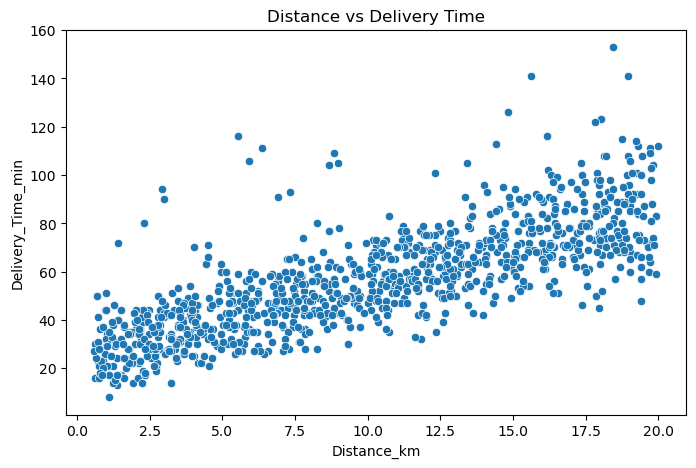

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df)
plt.title('Distance vs Delivery Time')
plt.savefig('../images/scatterplot.png')
plt.show()

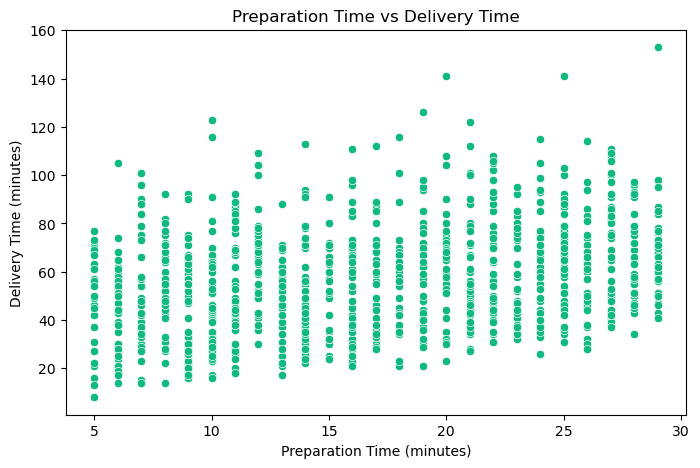

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Preparation_Time_min',
    y='Delivery_Time_min',
    data=df,
    color='#10B981'
)

plt.title('Preparation Time vs Delivery Time')

plt.xlabel('Preparation Time (minutes)')

plt.ylabel('Delivery Time (minutes)')

plt.savefig('../images/preparation_scatterplot.png')

plt.show()

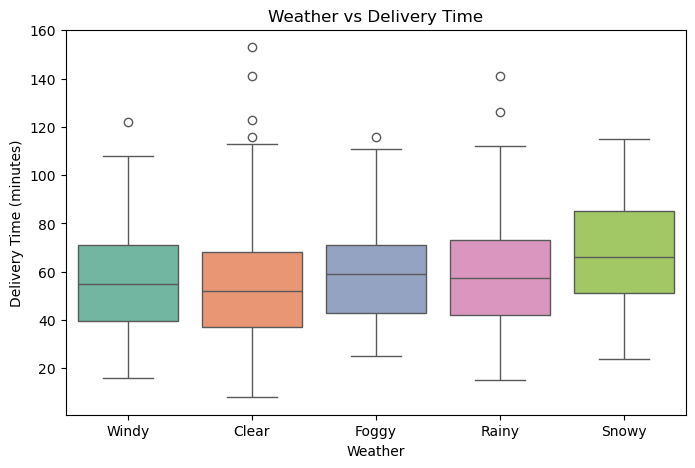

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Weather',
    y='Delivery_Time_min',
    hue='Weather',
    data=df,
    palette='Set2',
    legend=False
)

plt.title('Weather vs Delivery Time')

plt.xlabel('Weather')

plt.ylabel('Delivery Time (minutes)')
plt.savefig('../images/weather_boxplot.png')

plt.show()

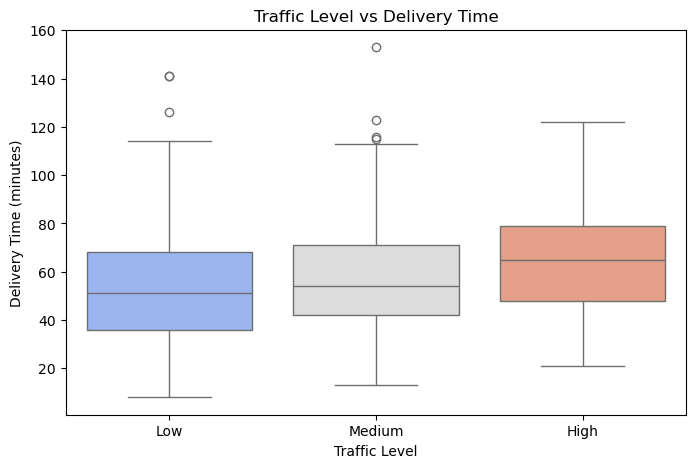

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Traffic_Level',
    y='Delivery_Time_min',
    hue='Traffic_Level',
    data=df,
    palette='coolwarm',
    legend=False
)

plt.title('Traffic Level vs Delivery Time')

plt.xlabel('Traffic Level')

plt.ylabel('Delivery Time (minutes)')
plt.savefig('../images/traffic_boxplot.png')
plt.show()

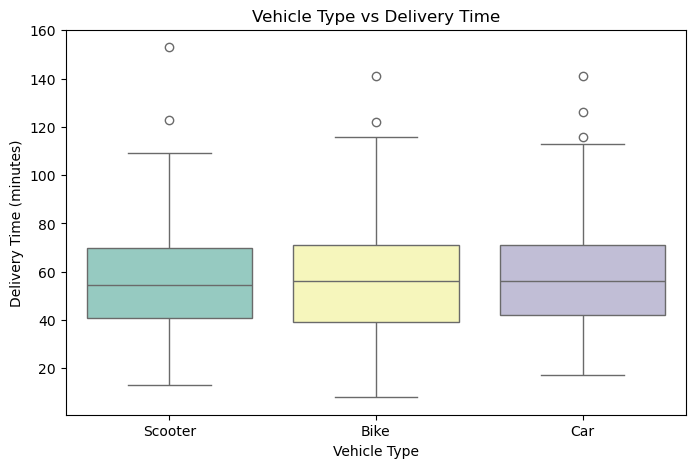

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Vehicle_Type',
    y='Delivery_Time_min',
    hue='Vehicle_Type',
    data=df,
    palette='Set3',
    legend=False
)

plt.title('Vehicle Type vs Delivery Time')

plt.xlabel('Vehicle Type')

plt.ylabel('Delivery Time (minutes)')
plt.savefig('../images/vehicle_boxplot.png')

plt.show()

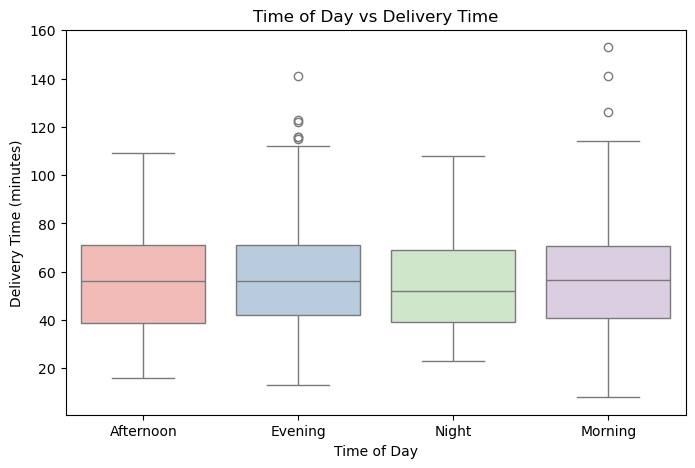

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Time_of_Day',
    y='Delivery_Time_min',
    hue='Time_of_Day',
    data=df,
    palette='Pastel1',
    legend=False
)

plt.title('Time of Day vs Delivery Time')

plt.xlabel('Time of Day')

plt.ylabel('Delivery Time (minutes)')
plt.savefig('../images/time_of_day_boxplot.png')

plt.show()

# Correlation Analysis

In [30]:
correlation = df.select_dtypes(include=['number']).corr()

correlation


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,z_score
Order_ID,1.000000,-0.024483,-0.035100,0.012933,-0.036650,-0.036650
Distance_km,-0.024483,1.000000,-0.009037,-0.007713,0.780998,0.780998
Preparation_Time_min,-0.035100,-0.009037,1.000000,-0.030353,0.307350,0.307350
Courier_Experience_yrs,0.012933,-0.007713,-0.030353,1.000000,-0.089066,-0.089066
Delivery_Time_min,-0.036650,0.780998,0.307350,-0.089066,1.000000,1.000000
z_score,-0.036650,0.780998,0.307350,-0.089066,1.000000,1.000000


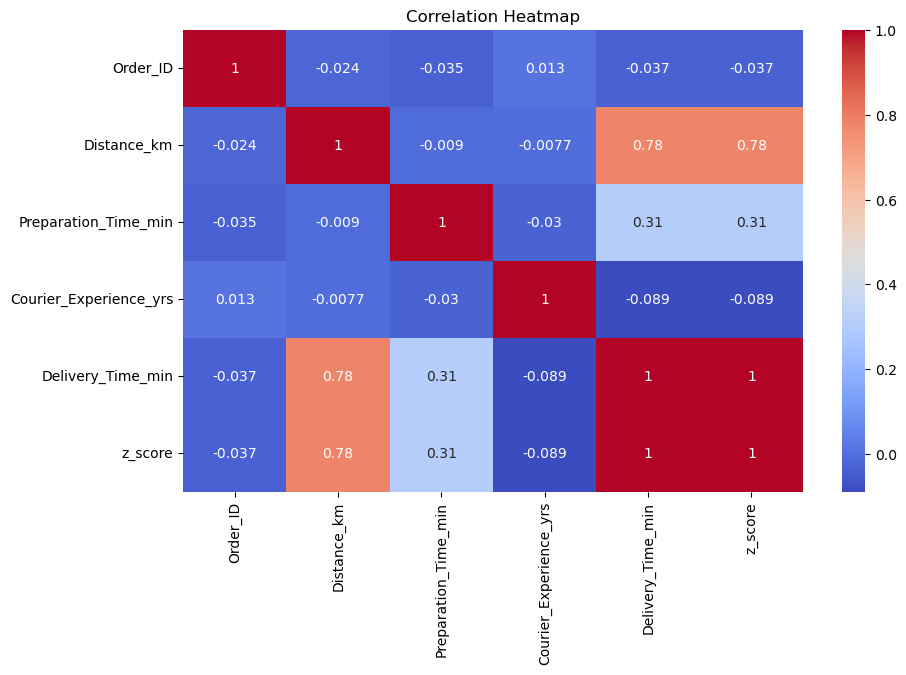

In [31]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig('../images/correlation_heatmap.png')
plt.show()

# Hypothesis analysis

In [32]:
from scipy.stats import f_oneway
low = df[df['Traffic_Level'] == 'Low']['Delivery_Time_min']

medium = df[df['Traffic_Level'] == 'Medium']['Delivery_Time_min']

high = df[df['Traffic_Level'] == 'High']['Delivery_Time_min']

f_stat, p_value = f_oneway(low, medium, high)

print("F-statistic:", f_stat)

print("P-value:", p_value)

F-statistic: 19.751338347737317
P-value: 3.86970694692799e-09


# Business Insights

## Key Insights

1. Traffic congestion significantly increases delivery time.

2. Longer delivery distances lead to higher delivery delays.

3. Adverse weather conditions negatively impact delivery performance.

4. High preparation time contributes to operational delays.

5. Some deliveries showed unusually high delivery times, indicating operational inefficiencies.

6. Delivery performance varies across different times of the day.

# Recommendations

- Improve route optimization during peak traffic hours.

- Implement weather-aware delivery planning systems.

- Reduce restaurant preparation delays.

- Increase delivery workforce during busy hours.

- Monitor extremely delayed deliveries for operational improvements.

# Conclusion

This project successfully analyzed factors affecting food delivery delays using data analytics techniques.

Traffic, distance, and weather conditions were identified as major factors influencing delivery performance.

The analysis demonstrates how data-driven insights can help improve operational efficiency and customer satisfaction.

# Save Cleaned Dataset

In [33]:
df.to_csv("../data/cleaned_food_delivery_times.csv", index=False)
print('\n Analysis complete. Cleaned data saved to ../data/cleaned_food_delivery_times.csv')


 Analysis complete. Cleaned data saved to ../data/cleaned_food_delivery_times.csv
